In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
single_cards_sim = np.random.randint(2,15,10000)

single_cards_sim.mean()

np.float64(7.9439)

In [41]:
# 13 cards to choose from, each value is the same of the face
# J = 11, Q = 12, K = 13, A = 14

# market make the sum of 3 random cards
def simulation(n=1000, include=np.arange(2, 15)):
    """Sum of 3 random cards drawn (with replacement) from the values in `include`.

    e.g. include=[3, 4, ..., 14] removes 2s from the deck.
    """
    include = np.asarray(include)
    sim = []

    for i in range(n):
        three_cards = np.random.choice(include, 3)  # only values in `include`
        sim.append(three_cards.sum())

    return np.array(sim)


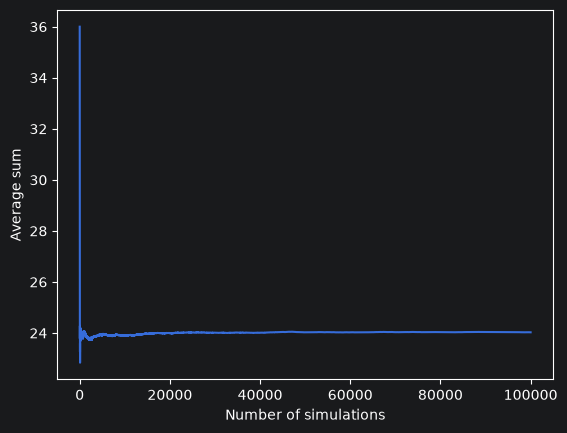

In [42]:
# Run 1000 simulations
sim = simulation(100000)

# Expanding mean
expanding_mean = np.cumsum(sim) / np.arange(1, len(sim) + 1)

# Plot
plt.plot(expanding_mean)
plt.xlabel("Number of simulations")
plt.ylabel("Average sum")
plt.show()

In [43]:
# run simulations on the mean and the variance for market events like
# odd numbers only vs even numbers only
# only numbers below 7 or above 10

In [44]:
# run simulations on the mean and the variance for market events like
# odd numbers only vs even numbers only
# only numbers below 7 or above 10
import pandas as pd

cards = np.arange(2, 15)

events = {
    "all cards":        cards,
    "odd only":         cards[cards % 2 == 1],
    "even only":        cards[cards % 2 == 0],
    "below 7":          cards[cards < 7],
    "above 10":         cards[cards > 10],
    "below 7 or above 10": cards[(cards < 7) | (cards > 10)],
}

n = 100_000
rows = []
for name, include in events.items():
    sim = simulation(n, include=include)
    # analytic: sum of 3 iid draws -> mean = 3*E[X], var = 3*Var[X]
    rows.append({
        "cards": ", ".join(map(str, include)),
        "sim_mean": sim.mean(),
        "true_mean": 3 * include.mean(),
        "sim_var": sim.var(),
        "true_var": 3 * include.var(),
        "sim_std": sim.std(),
    })

results = pd.DataFrame(rows, index=events.keys())
results.round(3)

,cards,sim_mean,true_mean,sim_var,true_var,sim_std
all cards,"2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14",23.983,24.000,41.892,42.000,6.472
odd only,"3, 5, 7, 9, 11, 13",23.996,24.000,34.853,35.000,5.904
even only,"2, 4, 6, 8, 10, 12, 14",24.004,24.000,48.137,48.000,6.938
below 7,"2, 3, 4, 5, 6",11.993,12.000,5.996,6.000,2.449
above 10,"11, 12, 13, 14",37.504,37.500,3.756,3.750,1.938
below 7 or above 10,"2, 3, 4, 5, 6, 11, 12, 13, 14",23.270,23.333,58.511,58.519,7.649


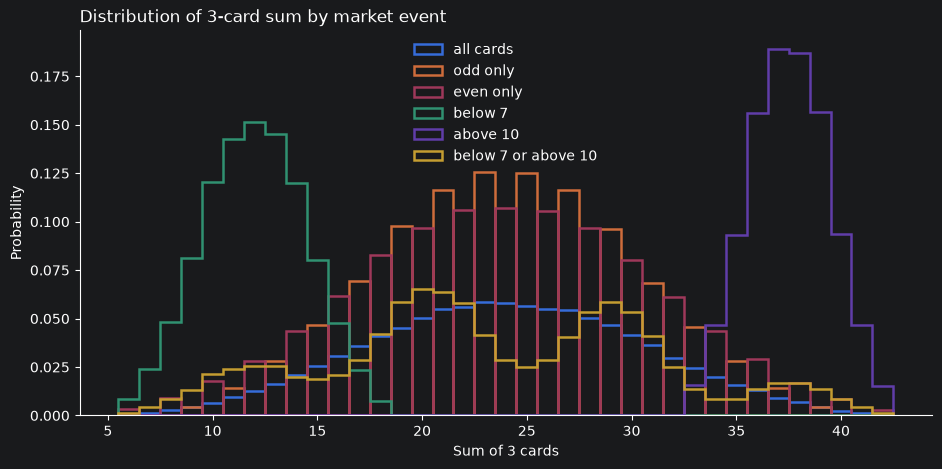

In [45]:
# distribution of the 3-card sum under each event
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.arange(5.5, 43.5, 1)
for name, include in events.items():
    sim = simulation(n, include=include)
    ax.hist(sim, bins=bins, density=True, histtype="step", linewidth=1.8, label=name)

ax.set_title("Distribution of 3-card sum by market event", loc="left")
ax.set_xlabel("Sum of 3 cards")
ax.set_ylabel("Probability")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()